In [1]:
import warnings, re, json, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import sparse

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report, recall_score

CLASS_ORDER  = ['CLASS - 1', 'CLASS - 2', 'CLASS - 3']
CLASS_COLORS = {'CLASS - 1': '#2a78d6', 'CLASS - 2': '#eb6834', 'CLASS - 3': '#1baf7a'}
NEUTRAL = '#2a78d6'
sns.set_theme(style='whitegrid', rc={'axes.titleweight': 'bold', 'grid.color': '#eeeeee'})
pd.set_option('display.max_colwidth', 120)

DATA_PATH = '../data/raw/DOB_ECB_Violations_20260929.csv'
OUT_DIR = 'artifacts'; os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_STATE = 42
TARGET = 'SEVERITY'

In [2]:
#load raw data
raw = pd.read_csv(DATA_PATH, dtype=str, low_memory=False)   # strings: protect codes & leading zeros [EDA §1]
print(raw.shape)
# Guard: keep only valid target labels (EDA found none invalid / "Unknown", but the pipeline must be robust)
valid = raw[TARGET].isin(CLASS_ORDER)
print('Rows with invalid/unknown target removed:', (~valid).sum())
df = raw[valid].copy()

(156749, 46)
Rows with invalid/unknown target removed: 0


In [3]:
#data cleaning
#remove duplicates & re entery
ID_COLS = ['ISN_DOB_BIS_EXTRACT', 'ECB_VIOLATION_NUMBER']
non_id = [c for c in df.columns if c not in ID_COLS]
n0 = len(df)
df = df.drop_duplicates(subset=non_id, keep='first').reset_index(drop=True)
print(f'Duplicates removed: {n0 - len(df)}  ->  {len(df):,} rows')

Duplicates removed: 209  ->  156,540 rows


In [4]:
#drop coloumns with more missing values 100%
DROP = {}
for i in range(4, 11):
    DROP[f'INFRACTION_CODE{i}'] = 'empty (100% missing)'
    DROP[f'SECTION_LAW_DESCRIPTION{i}'] = 'empty (100% missing)'
for i in range(1, 4):
    DROP[f'INFRACTION_CODE{i}'] = 'LEAKAGE – code legally defines the class (1-feature tree ≈ 98% acc.)'
    DROP[f'SECTION_LAW_DESCRIPTION{i}'] = 'LEAKAGE – text version of the infraction code'
DROP.update({
 'PENALITY_IMPOSED':     'LEAKAGE – penalty schedule set by class; imposed at hearing',
 'AMOUNT_PAID':          'LEAKAGE / post-event – exists only after payment',
 'BALANCE_DUE':          'LEAKAGE / post-event – penalty minus payment',
 'HEARING_STATUS':       'post-event – hearing outcome (CURED/IN-VIO never Class 1)',
 'CERTIFICATION_STATUS': 'post-event – CURE ACCEPTED never Class 1',
 'ECB_VIOLATION_STATUS': 'post-event – current ACTIVE/RESOLVE status',
 'HEARING_DATE':         'post-event – rescheduled after adjournments',
 'HEARING_TIME':         'operational scheduling slot, no causal meaning',
 'SERVED_DATE':          'weak signal (lag = 0 for >75%), not always known at triage',
 'ISN_DOB_BIS_EXTRACT':  'identifier (unique per row)',
 'ECB_VIOLATION_NUMBER': 'identifier (unique per row)',
 'BLOCK':                'location identifier (10k levels); BORO + BIN history cover location',
 'LOT':                  'location identifier',
 'RESPONDENT_HOUSE_NUMBER': 'PII – respondent mailing address',
 'RESPONDENT_STREET':    'PII – respondent mailing address',
 'RESPONDENT_CITY':      'PII – mailing city, not the building location',
 'RESPONDENT_ZIP':       'PII – mailing ZIP, not the building location',
})
# Kept *temporarily* for feature engineering, dropped later: BIN, ISSUE_DATE, RESPONDENT_NAME, DOB_VIOLATION_NUMBER
drop_tbl = pd.DataFrame({'column': DROP.keys(), 'reason': DROP.values()})
display(drop_tbl)
df = df.drop(columns=list(DROP))
print('Remaining columns:', list(df.columns))

,column,reason
0,INFRACTION_CODE4,empty (100% missing)
1,SECTION_LAW_DESCRIPTION4,empty (100% missing)
2,INFRACTION_CODE5,empty (100% missing)
3,SECTION_LAW_DESCRIPTION5,empty (100% missing)
4,INFRACTION_CODE6,empty (100% missing)
5,SECTION_LAW_DESCRIPTION6,empty (100% missing)
6,INFRACTION_CODE7,empty (100% missing)
7,SECTION_LAW_DESCRIPTION7,empty (100% missing)
8,INFRACTION_CODE8,empty (100% missing)
9,SECTION_LAW_DESCRIPTION8,empty (100% missing)


Remaining columns: ['DOB_VIOLATION_NUMBER', 'BIN', 'BORO', 'ISSUE_DATE', 'SEVERITY', 'VIOLATION_TYPE', 'RESPONDENT_NAME', 'VIOLATION_DESCRIPTION', 'AGGRAVATED_LEVEL']


In [5]:
df['BIN'] = df['BIN'].where(~df['BIN'].str.fullmatch(r'[1-5]000000', na=False))
df['VIOLATION_DESCRIPTION'] = df['VIOLATION_DESCRIPTION'].fillna('')
df['RESPONDENT_NAME'] = df['RESPONDENT_NAME'].fillna('')
df['ISSUE_DATE'] = pd.to_datetime(df['ISSUE_DATE'], format='%Y%m%d', errors='raise')
print(df.isna().sum()[df.isna().sum() > 0])

DOB_VIOLATION_NUMBER    118365
BIN                        271
dtype: int64


In [6]:
#text cleaning and leckage masking
MONTHS = r'\b(JAN|JANUARY|FEB|FEBRUARY|MARCH|APRIL|JUNE|JULY|AUG|AUGUST|SEPT|SEPTEMBER|OCT|OCTOBER|NOV|NOVEMBER|DEC|DECEMBER)\b'

def clean_description(s: str) -> str:
    s = str(s).upper()
    s = re.sub(r'HTTPS?://\S+|WWW\.\S+', ' URL ', s)
    CLS = r'CLASS\s*[-#:.]?\s*[123](?![0-9])'
    s = re.sub(CLS, ' ', s)                                        # leakage masking
    s = re.sub(r'\bIMMEDIATELY\s+HAZARDOUS\b', ' ', s)
    s = re.sub(r'\b(MAJOR|LESSER)\b', ' ', s)
    s = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', ' DATE ', s)
    s = re.sub(MONTHS, ' DATE ', s)
    s = re.sub(r'\b[A-Z]{0,3}\d{6,}[A-Z0-9-]*\b', ' IDNUM ', s)    # permit / job / device numbers
    s = re.sub(r'[^A-Z0-9\.\-/ ]', ' ', s)
    s = re.sub(CLS, ' ', s)                                        # again: punctuation removal can create new matches
    return re.sub(r'\s+', ' ', s).strip()

df['DESC_CLEAN'] = df['VIOLATION_DESCRIPTION'].map(clean_description)
ex = df.loc[df['VIOLATION_DESCRIPTION'].str.contains(r'CLASS\s*[12]|/20|HTTP', regex=True),
            ['VIOLATION_DESCRIPTION', 'DESC_CLEAN']].head(5)
display(ex)
left = df['DESC_CLEAN'].str.contains(r'CLASS\s*[-#:.]?\s*[123](?![0-9])')
print('Rows still containing "CLASS n" after masking:', left.sum())
print(df.loc[left, 'DESC_CLEAN'].head(3).to_string())

,VIOLATION_DESCRIPTION,DESC_CLEAN
0,TEMP CONSTRUCTION EQUIP/INSTALLATION ON SITE EXPIRED PERMIT(SHED). AT TIME OF INSPECTION INSTALLED SIDEWALK SHED PER...,TEMP CONSTRUCTION EQUIP/INSTALLATION ON SITE EXPIRED PERMIT SHED . AT TIME OF INSPECTION INSTALLED SIDEWALK SHED PER...
1,"UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER'S ORDER. FOR WORK WITHOUT A PERMIT FOR VIO#39162126K ,NO PERMIT O...",UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER S ORDER. FOR WORK WITHOUT A PERMIT FOR VIO IDNUM NO PERMIT ON FIL...
4,FAILURE TO COMPLY WITH THE COMMISSIONER'S ORDER TO FILE A CERTIFICATE OF CORRECTION WITH THE DEPARTMENT OF BUILDINGS...,FAILURE TO COMPLY WITH THE COMMISSIONER S ORDER TO FILE A CERTIFICATE OF CORRECTION WITH THE DEPARTMENT OF BUILDINGS...
18,"AT TIME OF INSPECTION, OBSERVED WORK CONTINUED DESPITE SWO ISSUED 12/20/2023 UNDER COMPLAINT #4945979 ORDERING ""STOP...",AT TIME OF INSPECTION OBSERVED WORK CONTINUED DESPITE SWO ISSUED DATE UNDER COMPLAINT IDNUM ORDERING STOP ALL INTERI...
27,CLASS 2:FAILURE TO MAINTAIN BUILDING IN CODE COMPLIANT MANNER. SERVICE ELEVATOR EQUIPMENT AS PER BC3001.2 & 27-987. ...,FAILURE TO MAINTAIN BUILDING IN CODE COMPLIANT MANNER. SERVICE ELEVATOR EQUIPMENT AS PER BC3001.2 27-987. UPON INSPE...


Rows still containing "CLASS n" after masking: 0
Series([], )


In [7]:
#feature engineering
# --- Date features
df['ISSUE_MONTH'] = df['ISSUE_DATE'].dt.month
df['ISSUE_DAYOFWEEK'] = df['ISSUE_DATE'].dt.dayofweek
df['IS_WEEKEND'] = (df['ISSUE_DAYOFWEEK'] >= 5).astype(int)

# --- Respondent type (domain rule-based normalisation of a PII field)
GOV = r'DEPARTMENT|DEPT|\bNYC\b|CITY OF|HOUSING AUTH|SCHOOL|BOARD OF ED|\bHPD\b|\bDOE\b|AUTHORITY|\bMTA\b|STATE OF'
ORG = (r'\bLLC\b|\bINC\b|CORP|\bCO\b|LTD|\bLP\b|ASSOC|REALTY|MGMT|MANAGEMENT|TRUST|CONDO|CONSTRUCT|DEVELOP|PROPERT|'
       r'HOLDING|GROUP|BUILDERS|CONTRACT|SERVICES|ENTERPRISE|OWNER|CHURCH|HOSPITAL|UNIVERSITY|COOP|CO-OP|HDFC|L\.L\.C')
def respondent_type(name: str) -> str:
    n = str(name).upper().strip()
    if not n: return 'UNKNOWN'
    if re.search(GOV, n): return 'GOVERNMENT'
    if re.search(ORG, n): return 'ORGANISATION'
    return 'INDIVIDUAL'
df['RESPONDENT_TYPE'] = df['RESPONDENT_NAME'].map(respondent_type)

# --- DOB violation number: informative missingness + issuing unit code
df['HAS_DOB_VIOLATION'] = df['DOB_VIOLATION_NUMBER'].notna().astype(int)
df['DOB_UNIT'] = df['DOB_VIOLATION_NUMBER'].str.extract(r'^\d{8}([A-Z]+)')[0].str[:4].fillna('NONE')

# --- Ordinal aggravation level
df['AGGRAVATED_ORD'] = df['AGGRAVATED_LEVEL'].map({'NO': 0, 'AGGRAVATED OFFENSE LEVEL 1': 1,
                                                    'AGGRAVATED OFFENSE LEVEL 2': 2}).fillna(0).astype(int)
# --- Text length
df['DESC_WORDS'] = df['DESC_CLEAN'].str.split().str.len()
df[['ISSUE_MONTH', 'IS_WEEKEND', 'RESPONDENT_TYPE', 'HAS_DOB_VIOLATION', 'DOB_UNIT', 'AGGRAVATED_ORD', 'DESC_WORDS']].head()

,ISSUE_MONTH,IS_WEEKEND,RESPONDENT_TYPE,HAS_DOB_VIOLATION,DOB_UNIT,AGGRAVATED_ORD,DESC_WORDS
0,8,0,INDIVIDUAL,0,NONE,0,30
1,6,0,INDIVIDUAL,0,NONE,0,30
2,7,0,ORGANISATION,0,NONE,0,29
3,4,0,GOVERNMENT,1,CDOE,0,30
4,9,0,INDIVIDUAL,0,NONE,0,35


In [8]:
def add_bin_history(frame: pd.DataFrame) -> pd.DataFrame:
    f = frame[['BIN', 'ISSUE_DATE', TARGET]].copy()
    f['is_c1'] = (f[TARGET] == 'CLASS - 1').astype(int)
    day = (f.dropna(subset=['BIN']).groupby(['BIN', 'ISSUE_DATE'])
             .agg(n=('is_c1', 'size'), c1=('is_c1', 'sum')).reset_index()
             .sort_values(['BIN', 'ISSUE_DATE']))
    g = day.groupby('BIN')
    day['BIN_PRIOR_VIOLATIONS'] = g['n'].cumsum() - day['n']          # strictly earlier dates
    day['BIN_PRIOR_CLASS1']     = g['c1'].cumsum() - day['c1']
    day['BIN_DAYS_SINCE_PREV']  = g['ISSUE_DATE'].diff().dt.days      # gap to previous inspection date
    out = frame.merge(day[['BIN', 'ISSUE_DATE', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV']],
                      on=['BIN', 'ISSUE_DATE'], how='left')
    out['BIN_PRIOR_VIOLATIONS'] = out['BIN_PRIOR_VIOLATIONS'].fillna(0)
    out['BIN_PRIOR_CLASS1'] = out['BIN_PRIOR_CLASS1'].fillna(0)
    out['BIN_HAS_HISTORY'] = (out['BIN_PRIOR_VIOLATIONS'] > 0).astype(int)
    # no previous violation -> gap is undefined; cap at the observation window (1,000 days) and let the flag carry it
    out['BIN_DAYS_SINCE_PREV'] = out['BIN_DAYS_SINCE_PREV'].fillna(1000).clip(upper=1000)
    return out

df = add_bin_history(df)
# sanity check: a row's history must never include itself or later rows
chk = df[df.BIN.notna()].sort_values('ISSUE_DATE').groupby('BIN').head(1)
print('First-ever violation of each BIN has prior count 0:', (chk['BIN_PRIOR_VIOLATIONS'] == 0).all())
df[['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'BIN_HAS_HISTORY']].describe().round(2)

First-ever violation of each BIN has prior count 0: True


,BIN_PRIOR_VIOLATIONS,BIN_PRIOR_CLASS1,BIN_DAYS_SINCE_PREV,BIN_HAS_HISTORY
count,156540.00,156540.00,156540.00,156540.00
mean,2.25,0.97,613.69,0.47
std,4.38,2.39,428.20,0.50
min,0.00,0.00,1.00,0.00
25%,0.00,0.00,128.00,0.00
50%,0.00,0.00,1000.00,0.00
75%,3.00,1.00,1000.00,1.00
max,84.00,33.00,1000.00,1.00


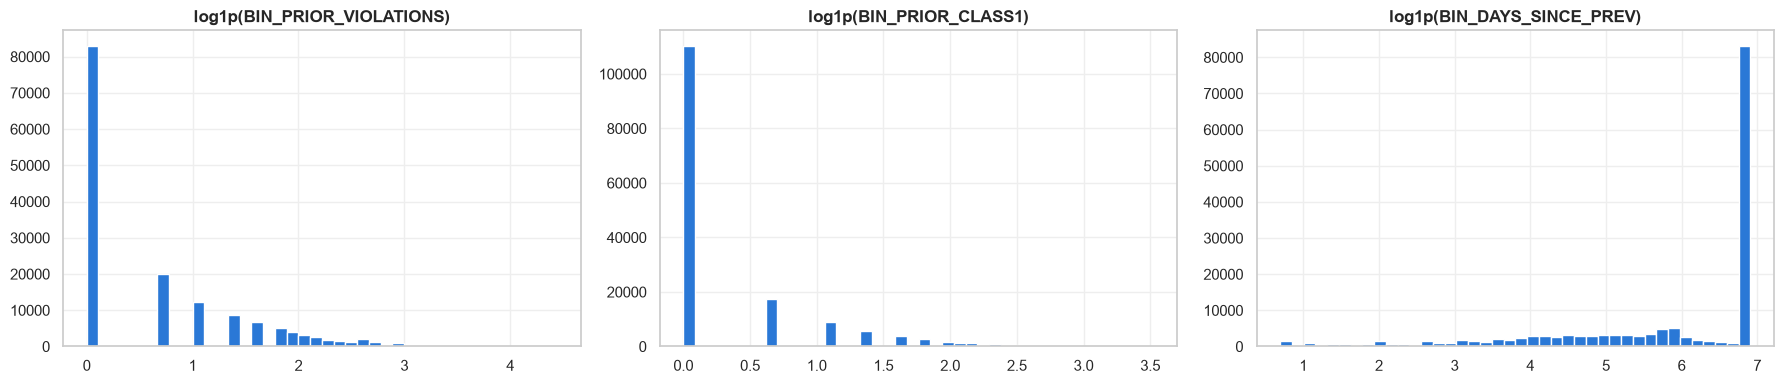

Skewness raw  : {'BIN_PRIOR_VIOLATIONS': 4.07, 'BIN_PRIOR_CLASS1': 4.47}
Skewness log1p: {'BIN_PRIOR_VIOLATIONS': 1.01, 'BIN_PRIOR_CLASS1': 1.75}


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, c in zip(axes, ['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV']):
    ax.hist(np.log1p(df[c]), bins=40, color=NEUTRAL); ax.set_title(f'log1p({c})')
plt.tight_layout(); plt.show()
print('Skewness raw  :', df[['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1']].skew().round(2).to_dict())
print('Skewness log1p:', np.log1p(df[['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1']]).skew().round(2).to_dict())

In [10]:
#final modeling table
TEXT_COL = 'DESC_CLEAN'
CAT_COLS = ['BORO', 'VIOLATION_TYPE', 'RESPONDENT_TYPE', 'DOB_UNIT', 'ISSUE_MONTH', 'ISSUE_DAYOFWEEK']
BIN_COLS = ['IS_WEEKEND', 'HAS_DOB_VIOLATION', 'BIN_HAS_HISTORY']
NUM_COLS = ['AGGRAVATED_ORD', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'DESC_WORDS']
FEATURES = [TEXT_COL] + CAT_COLS + BIN_COLS + NUM_COLS

model_df = df[FEATURES + ['ISSUE_DATE', TARGET]].copy()
model_df[CAT_COLS] = model_df[CAT_COLS].astype(str)
print(model_df.shape); model_df.head()

(156540, 17)


,DESC_CLEAN,BORO,VIOLATION_TYPE,RESPONDENT_TYPE,DOB_UNIT,ISSUE_MONTH,ISSUE_DAYOFWEEK,IS_WEEKEND,HAS_DOB_VIOLATION,BIN_HAS_HISTORY,AGGRAVATED_ORD,BIN_PRIOR_VIOLATIONS,BIN_PRIOR_CLASS1,BIN_DAYS_SINCE_PREV,DESC_WORDS,ISSUE_DATE,SEVERITY
0,TEMP CONSTRUCTION EQUIP/INSTALLATION ON SITE EXPIRED PERMIT SHED . AT TIME OF INSPECTION INSTALLED SIDEWALK SHED PER...,1,Unknown,INDIVIDUAL,NONE,8,1,0,0,0,0,0.0,0.0,1000.0,30,2025-08-05,CLASS - 2
1,UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER S ORDER. FOR WORK WITHOUT A PERMIT FOR VIO IDNUM NO PERMIT ON FIL...,5,Construction,INDIVIDUAL,NONE,6,2,0,0,1,0,6.0,6.0,85.0,30,2026-06-24,CLASS - 1
2,3307.6.5.4 OBSERVED MULTIPLE LOCATIONS WHERE CONSTRUCTION MATERIALS WERE STORED ON THE SIDEWALK SHED MATERIALS WERE ...,1,Unknown,ORGANISATION,NONE,7,3,0,0,1,0,2.0,1.0,465.0,29,2026-07-02,CLASS - 2
3,FAILURE TO MAINTAIN BUILDING WALL S OR APPURTENANCES. NOTED AT NEW EXTENSION/LOWER ROOF WATER PENETRATION TO INTERIO...,4,Construction,GOVERNMENT,CDOE,4,3,0,1,0,0,0.0,0.0,1000.0,30,2024-04-25,CLASS - 2
4,FAILURE TO COMPLY WITH THE COMMISSIONER S ORDER TO FILE A CERTIFICATE OF CORRECTION WITH THE DEPARTMENT OF BUILDINGS...,3,Construction,INDIVIDUAL,NONE,9,2,0,0,1,0,5.0,1.0,49.0,35,2026-09-02,CLASS - 2


In [11]:
#train/test split
model_df = model_df.sort_values('ISSUE_DATE', kind='mergesort').reset_index(drop=True)
cutoff = model_df['ISSUE_DATE'].quantile(0.80)
train_df = model_df[model_df.ISSUE_DATE < cutoff].copy()
test_df  = model_df[model_df.ISSUE_DATE >= cutoff].copy()
print(f'Cutoff date: {cutoff.date()}')
print(f'Train: {len(train_df):,} rows  {train_df.ISSUE_DATE.min().date()} → {train_df.ISSUE_DATE.max().date()}')
print(f'Test : {len(test_df):,} rows  {test_df.ISSUE_DATE.min().date()} → {test_df.ISSUE_DATE.max().date()}')
dist = pd.DataFrame({'train_%': train_df[TARGET].value_counts(normalize=True)*100,
                     'test_%':  test_df[TARGET].value_counts(normalize=True)*100}).reindex(CLASS_ORDER).round(2)
print(dist)

y_train, y_test = train_df[TARGET], test_df[TARGET]

# time-ordered validation slice inside TRAIN (last 20% of train) for preprocessing/feature-selection decisions
vcut = train_df['ISSUE_DATE'].quantile(0.80)
sub_tr, sub_va = train_df[train_df.ISSUE_DATE < vcut], train_df[train_df.ISSUE_DATE >= vcut]
print(f'\nInner split for decisions: sub-train {len(sub_tr):,} | validation {len(sub_va):,} (from {vcut.date()})')

Cutoff date: 2026-04-02
Train: 125,207 rows  2024-01-01 → 2026-04-01
Test : 31,333 rows  2026-04-02 → 2026-09-24
           train_%  test_%
SEVERITY                  
CLASS - 1    39.30   39.82
CLASS - 2    56.32   56.60
CLASS - 3     4.38    3.58

Inner split for decisions: sub-train 100,163 | validation 25,044 (from 2025-10-26)


In [12]:
#encoridng scaling and text vectorization
log_minmax = Pipeline([('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
                       ('scale', MinMaxScaler(clip=True))])

def make_preprocessor(max_features=40000, bin_cols=BIN_COLS, num_cols=NUM_COLS):
    return ColumnTransformer([
        ('text', TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9, sublinear_tf=True,
                                 max_features=max_features, lowercase=False,
                                 token_pattern=r'(?u)\b[A-Z]{2,}\b|\b\d+-\d+(?:\.\d+)*\b'), TEXT_COL),
        ('cat',  OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=50, sparse_output=True), CAT_COLS),
        ('bin',  'passthrough', bin_cols),
        ('num',  log_minmax, num_cols),
    ], sparse_threshold=1.0, verbose_feature_names_out=True)

pre_probe = make_preprocessor().fit(sub_tr[FEATURES])           # fitted on SUB-TRAIN only
Xs_tr, Xs_va = pre_probe.transform(sub_tr[FEATURES]), pre_probe.transform(sub_va[FEATURES])
names_probe = pre_probe.get_feature_names_out()
blocks = pd.Series([n.split('__')[0] for n in names_probe]).value_counts()
print('Matrix shape (sub-train):', Xs_tr.shape, '| density: %.4f%%' % (Xs_tr.nnz / np.prod(Xs_tr.shape) * 100))
print(blocks)
print('One-hot categories kept (rare merged):')
for c, cats in zip(CAT_COLS, pre_probe.named_transformers_['cat'].categories_):
    inf = pre_probe.named_transformers_['cat'].infrequent_categories_[CAT_COLS.index(c)]
    print(f'  {c:16s} {len(cats):3d} levels, infrequent merged: {list(inf) if inf is not None else []}')

Matrix shape (sub-train): (100163, 40077) | density: 0.1418%
text    40000
cat        69
num         5
bin         3
Name: count, dtype: int64
One-hot categories kept (rare merged):
  BORO               5 levels, infrequent merged: []
  VIOLATION_TYPE    12 levels, infrequent merged: ['Public Assembly']
  RESPONDENT_TYPE    4 levels, infrequent merged: []
  DOB_UNIT         180 levels, infrequent merged: ['AERT', 'AHRT', 'AHVG', 'AHVJ', 'ALT', 'AMMT', 'ASPO', 'BDOE', 'BR', 'CADG', 'CAHC', 'CAHG', 'CAHJ', 'CAHL', 'CAHV', 'CB', 'CC', 'CCDM', 'CCEB', 'CCER', 'CCFA', 'CCHP', 'CDCT', 'CDCW', 'CDOB', 'CDOC', 'CE', 'CEB', 'CEDC', 'CER', 'CERA', 'CERE', 'CERF', 'CERG', 'CERK', 'CERM', 'CERP', 'CERT', 'CERW', 'CEUH', 'CEUJ', 'CGF', 'CH', 'CLLF', 'CM', 'CMDI', 'CMDL', 'CMFE', 'CMFM', 'CMTC', 'CNED', 'CNEE', 'CNEF', 'CNEK', 'CNEW', 'COBM', 'CODE', 'CON', 'CONS', 'COSI', 'COSP', 'CQND', 'CR', 'CRCM', 'CRDV', 'CRFD', 'CRGJ', 'CRRC', 'CRRR', 'CRT', 'CRTA', 'CRTC', 'CRTD', 'CRTE', 'CRTH', 'CRTJ', 'CR

In [13]:
#class imbalance handling
classes = np.array(CLASS_ORDER)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
CLASS_WEIGHTS = {str(k): float(round(v, 3)) for k, v in zip(classes, cw)}
print('Balanced class weights (train):', CLASS_WEIGHTS)
print('-> a Class 3 error costs ~%.0fx a Class 2 error during training' % (CLASS_WEIGHTS['CLASS - 3'] / CLASS_WEIGHTS['CLASS - 2']))

Balanced class weights (train): {'CLASS - 1': 0.848, 'CLASS - 2': 0.592, 'CLASS - 3': 7.613}
-> a Class 3 error costs ~13x a Class 2 error during training


In [14]:
#feature selection
#variance filter
struct_idx = [i for i, n in enumerate(names_probe) if not n.startswith('text__')]
Xstruct = Xs_tr[:, struct_idx].toarray()
var = pd.Series(Xstruct.var(axis=0), index=names_probe[struct_idx]).sort_values()
print('Lowest-variance structured features:'); print(var.head(8).round(5))
print('\nFeatures with variance < 1e-4:', list(var[var < 1e-4].index))

Lowest-variance structured features:
cat__VIOLATION_TYPE_infrequent_sklearn    0.00012
cat__DOB_UNIT_FALL                        0.00054
cat__DOB_UNIT_LLFJ                        0.00055
cat__DOB_UNIT_CRTT                        0.00056
cat__DOB_UNIT_CRTB                        0.00058
cat__DOB_UNIT_CRTG                        0.00066
cat__DOB_UNIT_CERR                        0.00073
cat__RESPONDENT_TYPE_UNKNOWN              0.00073
dtype: float64

Features with variance < 1e-4: []


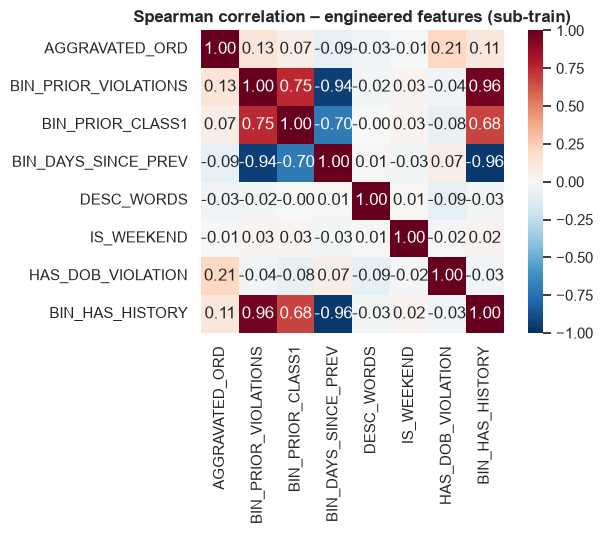

Pairs with |rho| > 0.85: [('BIN_PRIOR_VIOLATIONS', 'BIN_DAYS_SINCE_PREV', np.float64(-0.94)), ('BIN_PRIOR_VIOLATIONS', 'BIN_HAS_HISTORY', np.float64(0.96)), ('BIN_DAYS_SINCE_PREV', 'BIN_HAS_HISTORY', np.float64(-0.96))]

Spearman among rows WITH history:
                      BIN_PRIOR_VIOLATIONS  BIN_PRIOR_CLASS1  \
BIN_PRIOR_VIOLATIONS                  1.00              0.62   
BIN_PRIOR_CLASS1                      0.62              1.00   
BIN_DAYS_SINCE_PREV                  -0.22             -0.27   

                      BIN_DAYS_SINCE_PREV  
BIN_PRIOR_VIOLATIONS                -0.22  
BIN_PRIOR_CLASS1                    -0.27  
BIN_DAYS_SINCE_PREV                  1.00  


In [15]:
#correlation among numerical features
nums = sub_tr[NUM_COLS + BIN_COLS].astype(float)
cm = nums.corr(method='spearman')
plt.figure(figsize=(7, 5.5)); sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True)
plt.title('Spearman correlation – engineered features (sub-train)'); plt.tight_layout(); plt.show()
high = [(a, b, round(cm.loc[a, b], 2)) for i, a in enumerate(cm) for b in cm.columns[i+1:] if abs(cm.loc[a, b]) > 0.85]
print('Pairs with |rho| > 0.85:', high)

# Is the redundancy real, or just the "no history" rows? -> re-check only buildings WITH history
wh = nums[nums.BIN_HAS_HISTORY == 1][['BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV']].corr('spearman')
print('\nSpearman among rows WITH history:'); print(wh.round(2))

In [16]:
BIN_COLS_FINAL = [c for c in BIN_COLS if c != 'BIN_HAS_HISTORY']
NUM_COLS_FINAL = NUM_COLS
FEATURES_FINAL = [TEXT_COL] + CAT_COLS + BIN_COLS_FINAL + NUM_COLS_FINAL
print('Final structured features:', CAT_COLS + BIN_COLS_FINAL + NUM_COLS_FINAL)

Final structured features: ['BORO', 'VIOLATION_TYPE', 'RESPONDENT_TYPE', 'DOB_UNIT', 'ISSUE_MONTH', 'ISSUE_DAYOFWEEK', 'IS_WEEKEND', 'HAS_DOB_VIOLATION', 'AGGRAVATED_ORD', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'DESC_WORDS']


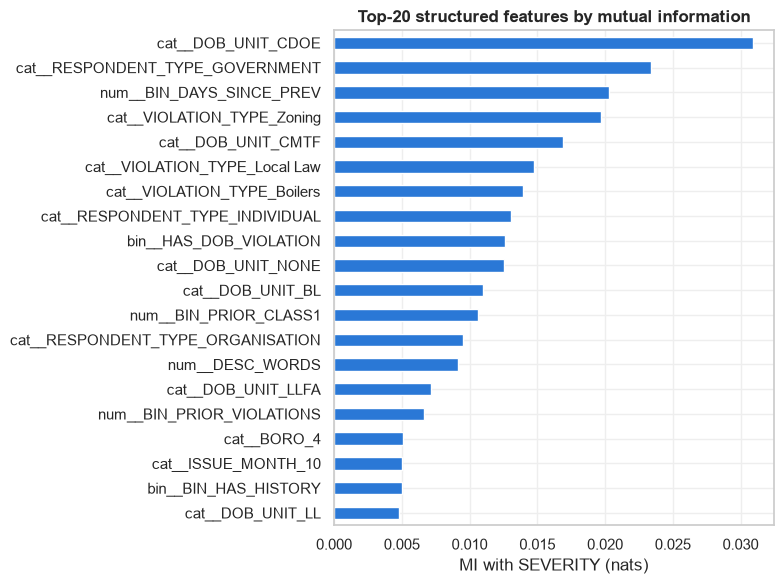

Zero-MI features: ['cat__ISSUE_MONTH_7', 'cat__ISSUE_MONTH_9', 'cat__DOB_UNIT_AMTF', 'cat__ISSUE_MONTH_5', 'cat__DOB_UNIT_CERR', 'cat__ISSUE_DAYOFWEEK_4', 'cat__ISSUE_DAYOFWEEK_3', 'cat__DOB_UNIT_CRTB', 'cat__ISSUE_DAYOFWEEK_1', 'cat__ISSUE_DAYOFWEEK_2', 'cat__DOB_UNIT_FALL', 'cat__DOB_UNIT_CRTG', 'cat__ISSUE_MONTH_3', 'cat__VIOLATION_TYPE_Plumbing', 'cat__DOB_UNIT_CRTT']


In [17]:
mi = mutual_info_classif(Xstruct, sub_tr[TARGET], discrete_features=True, random_state=RANDOM_STATE)
mi = pd.Series(mi, index=names_probe[struct_idx]).sort_values(ascending=False)
mi.head(20).iloc[::-1].plot(kind='barh', color=NEUTRAL, figsize=(8, 6), title='Top-20 structured features by mutual information')
plt.xlabel('MI with SEVERITY (nats)'); plt.tight_layout(); plt.show()
print('Zero-MI features:', list(mi[mi <= 1e-4].index))

In [18]:
# 7.4 Text vocabulary — chi² terms per class (sub-train)
text_idx = [i for i, n in enumerate(names_probe) if n.startswith('text__')]
Xt = Xs_tr[:, text_idx]; tnames = np.array([n.replace('text__', '') for n in names_probe[text_idx]])
top_terms = {}
for c in CLASS_ORDER:
    sc, _ = chi2(Xt, (sub_tr[TARGET] == c).astype(int))
    top_terms[c] = tnames[np.argsort(np.nan_to_num(sc))[::-1][:20]]
pd.DataFrame(top_terms)

,CLASS - 1,CLASS - 2,CLASS - 3
0,PARKING STRUCTURE,PARKING STRUCTURE,PERMITTED HEIGHT
1,STRUCTURE,STRUCTURE,EXCEEDS PERMITTED
2,REQUIRED PARKING,ACCEPTABLE,FENCE EXCEEDS
3,STRUCTURE INITIAL,PARKING,EXCEEDS
4,INITIAL OBSERVATION,REQUIRED PARKING,FRONT YARD
5,OBSERVATION REPORT,STRUCTURE INITIAL,ZONING
6,EXISTING PARKING,INITIAL OBSERVATION,PLANTING
7,PSID,EXISTING PARKING,CONFORM FENCE
8,DOCUMENTING THE,OBSERVATION REPORT,TO HEIGHT
9,OF PSID,PSID,RESOLUTION


In [ ]:
def eval_on_val(k, Xtr=Xs_tr, Xva=Xs_va):
    sel = SelectKBest(chi2, k=k).fit(Xtr, sub_tr[TARGET])
    clf = LinearSVC(C=0.5, class_weight='balanced', random_state=RANDOM_STATE).fit(sel.transform(Xtr), sub_tr[TARGET])
    p = clf.predict(sel.transform(Xva))
    return f1_score(sub_va[TARGET], p, average='macro'), recall_score(sub_va[TARGET], p, labels=['CLASS - 1'], average='macro')

ks = [1000, 3000, 5000, 10000, 20000, 'all']
curve = pd.DataFrame([(str(k), *eval_on_val(k)) for k in ks], columns=['k', 'val_macroF1', 'val_recall_C1'])
print(curve.round(4))
plt.figure(figsize=(7, 3.8)); plt.plot(curve.k, curve.val_macroF1, marker='o', color=NEUTRAL, lw=2)
plt.title('Validation macro-F1 vs number of selected features (chi²)'); plt.xlabel('k'); plt.ylabel('macro-F1')
plt.tight_layout(); plt.show()

In [ ]:
def ablation(keep_prefixes):
    idx = [i for i, n in enumerate(names_probe) if n.split('__')[0] in keep_prefixes]
    clf = LinearSVC(C=0.5, class_weight='balanced', random_state=RANDOM_STATE).fit(Xs_tr[:, idx], sub_tr[TARGET])
    p = clf.predict(Xs_va[:, idx])
    return round(f1_score(sub_va[TARGET], p, average='macro'), 4), round(recall_score(sub_va[TARGET], p, average=None, labels=CLASS_ORDER)[2], 4)

dummy = DummyClassifier(strategy='most_frequent').fit(Xs_tr, sub_tr[TARGET])
abl = pd.DataFrame({
 'Baseline: majority class':        (round(f1_score(sub_va[TARGET], dummy.predict(Xs_va), average='macro'), 4), 0.0),
 'Structured only (cat+bin+num)':   ablation({'cat', 'bin', 'num'}),
 'Text only (TF-IDF)':              ablation({'text'}),
 'Text + categorical':              ablation({'text', 'cat'}),
 'All features':                    ablation({'text', 'cat', 'bin', 'num'}),
}, index=['val_macroF1', 'val_recall_C3']).T
abl

,val_macroF1,val_recall_C3
Baseline: majority class,0.2355,0.0000
Structured only (cat+bin+num),0.4742,0.5364
Text only (TF-IDF),0.7569,0.7185
Text + categorical,0.7664,0.7254
All features,0.7696,0.7254


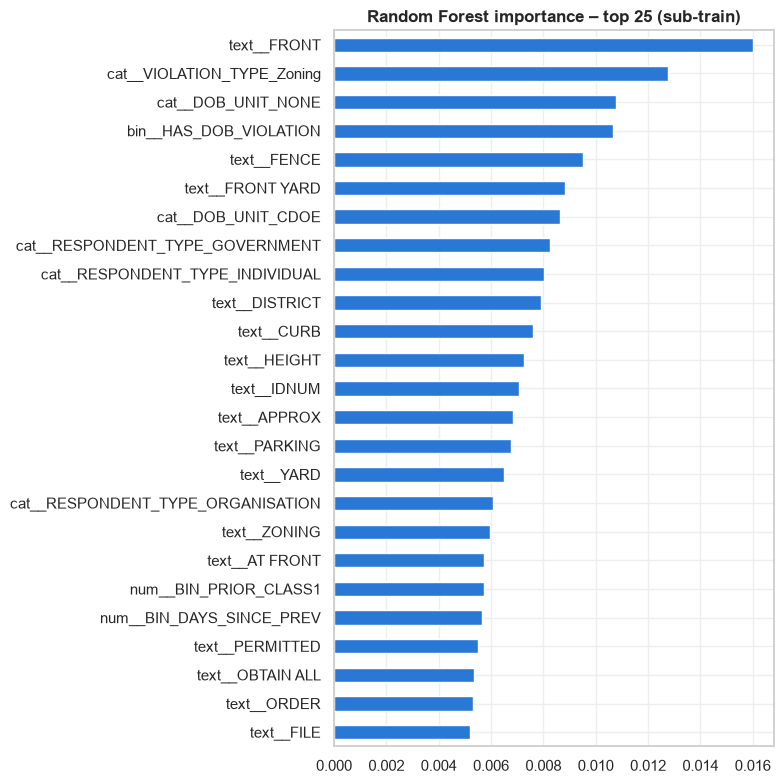

Importance share by feature group:
 text    0.875
cat     0.093
num     0.019
bin     0.014
dtype: float64

RF (sanity) validation macro-F1: 0.7314


In [ ]:
# Model-based importance: Random Forest on a sub-sample of sub-train (non-linear view), top-k chi2 text + all structured
k_rf = 5000
sel_rf = SelectKBest(chi2, k=k_rf).fit(Xs_tr, sub_tr[TARGET])
Xrf = sel_rf.transform(Xs_tr); rf_names = names_probe[sel_rf.get_support()]
rng = np.random.RandomState(RANDOM_STATE); samp = rng.choice(Xrf.shape[0], size=min(40000, Xrf.shape[0]), replace=False)
rf = RandomForestClassifier(n_estimators=150, min_samples_leaf=2, max_features='sqrt', class_weight='balanced',
                            n_jobs=-1, random_state=RANDOM_STATE).fit(Xrf[samp], sub_tr[TARGET].values[samp])
imp = pd.Series(rf.feature_importances_, index=rf_names).sort_values(ascending=False)
imp.head(25).iloc[::-1].plot(kind='barh', color=NEUTRAL, figsize=(8, 8), title='Random Forest importance – top 25 (sub-train)')
plt.tight_layout(); plt.show()
grp = imp.groupby(lambda n: n.split('__')[0]).sum().sort_values(ascending=False)
print('Importance share by feature group:\n', grp.round(3))
p_rf = rf.predict(sel_rf.transform(Xs_va))
print('\nRF (sanity) validation macro-F1:', round(f1_score(sub_va[TARGET], p_rf, average='macro'), 4))

In [ ]:
#building the final pipeline
def build_preprocess(k):
    return Pipeline([('features', make_preprocessor(bin_cols=BIN_COLS_FINAL, num_cols=NUM_COLS_FINAL)),
                     ('select',   SelectKBest(chi2, k=k))])

X_train, X_test = train_df[FEATURES_FINAL], test_df[FEATURES_FINAL]
results = {}
for tag, k in [('linear', 'all'), ('tree', 5000)]:
    pp = build_preprocess(k)
    Xtr_ = pp.fit_transform(X_train, y_train)      # FIT on TRAIN only
    Xte_ = pp.transform(X_test)                    # TRANSFORM test (no refit!)
    names_ = pp.named_steps['features'].get_feature_names_out()[pp.named_steps['select'].get_support()]
    results[tag] = (pp, Xtr_, Xte_, names_)
    print(f'[{tag}] k={k}: train {Xtr_.shape} | test {Xte_.shape} | groups',
          pd.Series([n.split('__')[0] for n in names_]).value_counts().to_dict())

preprocess, Xtr_final, Xte_final, feat_names = results['linear']

[linear] k=all: train (125207, 40078) | test (31333, 40078) | groups {'text': 40000, 'cat': 71, 'num': 5, 'bin': 2}
[tree] k=5000: train (125207, 5000) | test (31333, 5000) | groups {'text': 4932, 'cat': 62, 'num': 4, 'bin': 2}


In [ ]:
#leckage safety check
checks = {
 'No leakage columns in model input':  not any(c in FEATURES_FINAL for c in DROP),
 'Train dates all before test dates':  X_train.index.size and train_df.ISSUE_DATE.max() < test_df.ISSUE_DATE.min(),
 'Vocabulary learned from train only': True,   # preprocess.fit used X_train only (see cell above)
 'Test transformed, not refit':        True,
 'Scaled values in [0,1] on test (clip)': float(Xte_final.max()) <= 1.0 + 1e-9 and float(Xte_final.min()) >= 0,
}
pd.Series(checks, name='passed').to_frame()

,passed
No leakage columns in model input,True
Train dates all before test dates,True
Vocabulary learned from train only,True
"Test transformed, not refit",True
"Scaled values in [0,1] on test (clip)",True


In [ ]:
for tag, (pp, Xtr_, Xte_, names_) in results.items():
    joblib.dump(pp, f'{OUT_DIR}/preprocess_{tag}.joblib')
    sparse.save_npz(f'{OUT_DIR}/X_train_{tag}.npz', Xtr_.tocsr())
    sparse.save_npz(f'{OUT_DIR}/X_test_{tag}.npz',  Xte_.tocsr())
    pd.Series(names_, name='feature').to_csv(f'{OUT_DIR}/feature_names_{tag}.csv', index=False)
y_train.to_csv(f'{OUT_DIR}/y_train.csv', index=False); y_test.to_csv(f'{OUT_DIR}/y_test.csv', index=False)
train_df.to_csv(f'{OUT_DIR}/train_engineered.csv', index=False); test_df.to_csv(f'{OUT_DIR}/test_engineered.csv', index=False)

# history lookup for deployment: cumulative state of every building at the end of the data
hist = (df.dropna(subset=['BIN']).groupby('BIN')
          .agg(total_violations=(TARGET, 'size'),
               total_class1=(TARGET, lambda s: (s == 'CLASS - 1').sum()),
               last_issue_date=('ISSUE_DATE', 'max')).reset_index())
hist.to_csv(f'{OUT_DIR}/bin_history_lookup.csv', index=False)

json.dump(CLASS_WEIGHTS, open(f'{OUT_DIR}/class_weights.json', 'w'), indent=2)
json.dump({'features': FEATURES_FINAL, 'text_col': TEXT_COL, 'cat_cols': CAT_COLS, 'bin_cols': BIN_COLS_FINAL,
           'num_cols': NUM_COLS_FINAL, 'k_linear': 'all', 'k_tree': 5000, 'split_cutoff': str(cutoff.date()),
           'dropped_columns': DROP}, open(f'{OUT_DIR}/preprocessing_config.json', 'w'), indent=2)
print(sorted(os.listdir(OUT_DIR)))

['X_test_linear.npz', 'X_test_tree.npz', 'X_train_linear.npz', 'X_train_tree.npz', 'bin_history_lookup.csv', 'class_weights.json', 'feature_names_linear.csv', 'feature_names_tree.csv', 'preprocess_linear.joblib', 'preprocess_tree.joblib', 'preprocessing_config.json', 'test_engineered.csv', 'train_engineered.csv', 'y_test.csv', 'y_train.csv']


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156540 entries, 0 to 156539
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   DOB_VIOLATION_NUMBER   38175 non-null   str           
 1   BIN                    156269 non-null  str           
 2   BORO                   156540 non-null  str           
 3   ISSUE_DATE             156540 non-null  datetime64[us]
 4   SEVERITY               156540 non-null  str           
 5   VIOLATION_TYPE         156540 non-null  str           
 6   RESPONDENT_NAME        156540 non-null  str           
 7   VIOLATION_DESCRIPTION  156540 non-null  str           
 8   AGGRAVATED_LEVEL       156540 non-null  str           
 9   DESC_CLEAN             156540 non-null  str           
 10  ISSUE_MONTH            156540 non-null  int32         
 11  ISSUE_DAYOFWEEK        156540 non-null  int32         
 12  IS_WEEKEND             156540 non-null  int64         
